<a href="https://colab.research.google.com/github/arlinrus/vkr/blob/main/diplom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data load

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# %%capture
# !pip install --upgrade matplotlib numpy==1.26.0 # need refresh enviroment after installation

In [3]:
# %%capture
# !pip install basemap phik sweetviz

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import seaborn as sns


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
data_purchases = pd.read_csv('/content/drive/MyDrive/Diplom/amazon-purchases.csv', na_values=['NaN'])
data_purchases.head(10)

,Order Date,Purchase Price Per Unit,Quantity,Shipping Address State,Title,ASIN/ISBN (Product Code),Category,Survey ResponseID
0,2018-12-04,7.98,1.0,NJ,SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...,B0143RTB1E,FLASH_MEMORY,R_01vNIayewjIIKMF
1,2018-12-22,13.99,1.0,NJ,Betron BS10 Earphones Wired Headphones in Ear ...,B01MA1MJ6H,HEADPHONES,R_01vNIayewjIIKMF
2,2018-12-24,8.99,1.0,NJ,NaN,B078JZTFN3,NaN,R_01vNIayewjIIKMF
3,2018-12-25,10.45,1.0,NJ,Perfecto Stainless Steel Shaving Bowl. Durable...,B06XWF9HML,DISHWARE_BOWL,R_01vNIayewjIIKMF
4,2018-12-25,10.00,1.0,NJ,Proraso Shaving Cream for Men,B00837ZOI0,SHAVING_AGENT,R_01vNIayewjIIKMF
5,2019-02-18,10.99,1.0,NJ,Micro USB Cable Android Charger - Syncwire [2-...,B01GFB2E9M,COMPUTER_PROCESSOR,R_01vNIayewjIIKMF
6,2019-02-18,4.99,1.0,NJ,Amazon Basics USB 2.0 Charger Cable - A-Male t...,B00NH13S44,COMPUTER_ADD_ON,R_01vNIayewjIIKMF
7,2019-03-15,124.99,1.0,NJ,"Fire HD 8 Tablet (8"" HD Display, 32 GB, withou...",B077H6L7T9,AMAZON_TABLET,R_01vNIayewjIIKMF
8,2019-04-23,12.99,1.0,NJ,"Men's Leather Belt, Ratchet Dress Belt with Au...",B07L84ZZXC,APPAREL_BELT,R_01vNIayewjIIKMF
9,2019-04-23,24.69,1.0,NJ,NaN,B06XKNWJN2,NaN,R_01vNIayewjIIKMF


# DATA PREPROCESSING

In [7]:
import re

new_col_names = [
    re.sub(r"\s+", "_", s.strip().lower())
    for s in data_purchases.columns
]

In [8]:
data_purchases.columns = new_col_names

In [9]:
data_purchases.head()

,order_date,purchase_price_per_unit,quantity,shipping_address_state,title,asin/isbn_(product_code),category,survey_responseid
0,2018-12-04,7.98,1.0,NJ,SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...,B0143RTB1E,FLASH_MEMORY,R_01vNIayewjIIKMF
1,2018-12-22,13.99,1.0,NJ,Betron BS10 Earphones Wired Headphones in Ear ...,B01MA1MJ6H,HEADPHONES,R_01vNIayewjIIKMF
2,2018-12-24,8.99,1.0,NJ,NaN,B078JZTFN3,NaN,R_01vNIayewjIIKMF
3,2018-12-25,10.45,1.0,NJ,Perfecto Stainless Steel Shaving Bowl. Durable...,B06XWF9HML,DISHWARE_BOWL,R_01vNIayewjIIKMF
4,2018-12-25,10.00,1.0,NJ,Proraso Shaving Cream for Men,B00837ZOI0,SHAVING_AGENT,R_01vNIayewjIIKMF


In [10]:
data_purchases.rename(columns={'asin/isbn_(product_code)': 'asin_isbn'}, inplace=True)

In [11]:
data_purchases.columns

Index(['order_date', 'purchase_price_per_unit', 'quantity',
       'shipping_address_state', 'title', 'asin_isbn', 'category',
       'survey_responseid'],
      dtype='object')

In [12]:
# data_purchases['quantity'] = data_purchases['quantity'].astype(int)
# data_purchases['order_date'] = pd.to_datetime(data_purchases['order_date'])
# data_purchases[['title', 'asin_isbn', 'category','survey_responseid']] = data_purchases[['title', 'asin_isbn', 'category','survey_responseid']].astype(str)

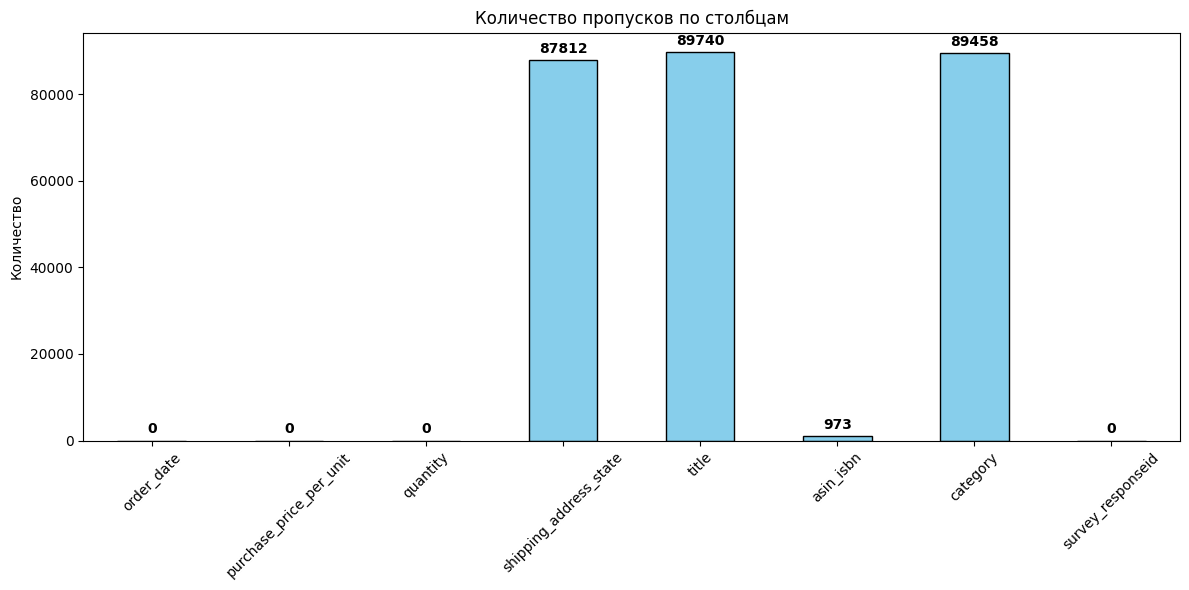

In [13]:
missing_value = data_purchases.isna().sum()
ax = missing_value.plot(kind='bar', legend=False, color='skyblue', edgecolor='black', linestyle='-', rot=45, figsize=(12,6))
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', padding=3, fontweight='bold')
plt.title('Количество пропусков по столбцам')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()

In [14]:
data_purchases.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1850717 entries, 0 to 1850716
Data columns (total 8 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   order_date               object 
 1   purchase_price_per_unit  float64
 2   quantity                 float64
 3   shipping_address_state   object 
 4   title                    object 
 5   asin_isbn                object 
 6   category                 object 
 7   survey_responseid        object 
dtypes: float64(2), object(6)
memory usage: 113.0+ MB


In [15]:
# from pathlib import Path

# filepath = Path("/content/drive/MyDrive/Diplom/data_purchases_.csv")
# data_purchases.to_csv(filepath, index=False)

In [16]:
data_purchases.dtypes

,0
order_date,object
purchase_price_per_unit,float64
quantity,float64
shipping_address_state,object
title,object
asin_isbn,object
category,object
survey_responseid,object


In [17]:
data_purchases.isnull().sum()


,0
order_date,0
purchase_price_per_unit,0
quantity,0
shipping_address_state,87812
title,89740
asin_isbn,973
category,89458
survey_responseid,0


Поработаем с пропусками в данных

Рассматорим **shipping_address_state**

In [18]:
data_purchases[data_purchases['shipping_address_state'].isna()]

,order_date,purchase_price_per_unit,quantity,shipping_address_state,title,asin_isbn,category,survey_responseid
32,2019-10-05,25.00,1.0,NaN,Best Buy Gift Cards - Email Delivery,B07RTN4C77,GIFT_CARD,R_01vNIayewjIIKMF
33,2019-10-06,50.00,1.0,NaN,Best Buy Gift Cards - Email Delivery,B07RTN4C77,GIFT_CARD,R_01vNIayewjIIKMF
34,2019-10-06,50.00,1.0,NaN,Best Buy Gift Cards - Email Delivery,B07RTN4C77,GIFT_CARD,R_01vNIayewjIIKMF
67,2020-03-03,10.00,1.0,NaN,$10 -PlayStation Store Gift Card [Digital Code],B00GAC1D2G,SCREEN_PROTECTOR,R_01vNIayewjIIKMF
72,2020-04-27,25.00,1.0,NaN,Best Buy Gift Cards - Email Delivery,B07RTN4C77,GIFT_CARD,R_01vNIayewjIIKMF
...,...,...,...,...,...,...,...,...
1850258,2020-09-05,6.98,1.0,NaN,"TUCKS Medicated Cooling Pads, 100 Count – Hemo...",B06ZYLFV8L,MEDICATION,R_zfnsck2ZatnGtY5
1850295,2020-11-29,25.00,1.0,NaN,Amazon.com Gift Card Balance Reload,B00IX1I3G6,GIFT_CARD,R_zfnsck2ZatnGtY5
1850407,2021-06-21,40.00,1.0,NaN,Amazon.com Gift Card Balance Reload,B00IX1I3G6,GIFT_CARD,R_zfnsck2ZatnGtY5
1850521,2022-05-21,54.99,1.0,NaN,Xbox Live Gold: 12 Month Membership [Digital C...,B002VBWIP6,DOWNLOADABLE_VIDEO_GAME,R_zfnsck2ZatnGtY5


Вероятно пользователи не ответили из какого штата они находятся, соответственно оставим эту информацию

In [19]:
data_purchases['shipping_address_state'] = data_purchases['shipping_address_state'].fillna('Uknown')

In [20]:
data_purchases[data_purchases['title'].isna()]

,order_date,purchase_price_per_unit,quantity,shipping_address_state,title,asin_isbn,category,survey_responseid
2,2018-12-24,8.99,1.0,NJ,NaN,B078JZTFN3,NaN,R_01vNIayewjIIKMF
9,2019-04-23,24.69,1.0,NJ,NaN,B06XKNWJN2,NaN,R_01vNIayewjIIKMF
36,2019-10-07,11.94,1.0,NJ,NaN,B07CZ6JCZS,NaN,R_01vNIayewjIIKMF
41,2019-10-18,14.26,1.0,NJ,NaN,B00KVM2SSO,NaN,R_01vNIayewjIIKMF
59,2019-12-22,14.33,1.0,NJ,NaN,B00KVM2SSO,NaN,R_01vNIayewjIIKMF
...,...,...,...,...,...,...,...,...
1850636,2023-01-19,39.68,1.0,OH,NaN,B09HY8XK6B,NaN,R_zfnsck2ZatnGtY5
1850648,2018-01-03,13.50,2.0,MA,NaN,B00BDJ5O26,NaN,R_zfqnsBzlOAKibzb
1850657,2018-03-15,23.00,1.0,MA,NaN,B00BDM0XZG,NaN,R_zfqnsBzlOAKibzb
1850700,2019-05-04,22.38,1.0,MA,NaN,B00BDM0XZG,NaN,R_zfqnsBzlOAKibzb


In [21]:
data_purchases['RESULT'] = np.where(
    data_purchases['title'].isna() & data_purchases['category'].isna(),
    'Yes',
    'No'
)

Посмотри сколько совпадает пропусков в товаре и категории у пользователей

In [22]:
count = data_purchases.groupby(['survey_responseid', 'RESULT']).size().unstack(fill_value=0).reset_index()
count.columns.name = None  # убираем имя 'RESULT' у колонок
count = count.rename(columns={'survey_responseid': 'check'})
count.sort_values(by='Yes', ascending=False)

,check,No,Yes
3884,R_8CXcySQawXPuJwJ,5057,358
2184,R_2ebzj3o225IisIQ,1884,324
4055,R_DIVJxjv1mP33pPb,857,264
1612,R_2EglJpTWGEiwQYa,4066,216
3916,R_9BuaSujzfvulXoJ,1904,187
...,...,...,...
2046,R_2bIBzFGLRT37EZT,30,0
1979,R_2ZKqoOzAsMTAnNk,48,0
1976,R_2ZIvE4bPXZXhf0T,9,0
2059,R_2bVhRIlk0QpQuYi,33,0


In [23]:
data_purchases['category'] = data_purchases['category'].fillna('Uknown')

In [24]:
data_purchases['title'] = data_purchases['title'].fillna('Uknown')

In [25]:
data_purchases.head()

,order_date,purchase_price_per_unit,quantity,shipping_address_state,title,asin_isbn,category,survey_responseid,RESULT
0,2018-12-04,7.98,1.0,NJ,SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...,B0143RTB1E,FLASH_MEMORY,R_01vNIayewjIIKMF,No
1,2018-12-22,13.99,1.0,NJ,Betron BS10 Earphones Wired Headphones in Ear ...,B01MA1MJ6H,HEADPHONES,R_01vNIayewjIIKMF,No
2,2018-12-24,8.99,1.0,NJ,Uknown,B078JZTFN3,Uknown,R_01vNIayewjIIKMF,Yes
3,2018-12-25,10.45,1.0,NJ,Perfecto Stainless Steel Shaving Bowl. Durable...,B06XWF9HML,DISHWARE_BOWL,R_01vNIayewjIIKMF,No
4,2018-12-25,10.00,1.0,NJ,Proraso Shaving Cream for Men,B00837ZOI0,SHAVING_AGENT,R_01vNIayewjIIKMF,No


In [26]:
data_purchases.isnull().sum()

,0
order_date,0
purchase_price_per_unit,0
quantity,0
shipping_address_state,0
title,0
asin_isbn,973
category,0
survey_responseid,0
RESULT,0


In [27]:
data_purchases[data_purchases['asin_isbn'].isna()]

,order_date,purchase_price_per_unit,quantity,shipping_address_state,title,asin_isbn,category,survey_responseid,RESULT
94027,2018-02-08,100.00,1.0,Uknown,Amazon.com eGift Card,NaN,GIFT_XXRD,R_1FPtnyDUi83F045,No
94028,2020-12-01,5.99,1.0,Uknown,Leg Avenue Women's Lurex Shimmer Anklet Socks,NaN,SOCKS,R_1FPtnyDUi83F045,No
94029,2020-12-01,36.99,1.0,Uknown,Women's Vintage Bow Tie High Heel Mary Janes P...,NaN,SHOES,R_1FPtnyDUi83F045,No
94030,2021-08-07,50.00,1.0,Uknown,Amazon eGift Card - Birthday Cupcakes,NaN,GIFT_XXRD,R_1FPtnyDUi83F045,No
94031,2021-09-08,50.00,1.0,Uknown,Amazon eGift Card - Birthday Cupcakes,NaN,GIFT_XXRD,R_1FPtnyDUi83F045,No
...,...,...,...,...,...,...,...,...,...
1284229,2023-02-24,17.99,1.0,Uknown,HERBAMAMA Goldenseal Root Capsule Supplement -...,NaN,Uknown,R_3lv2H1k8zdvXdkZ,No
1284230,2023-03-05,39.99,1.0,Uknown,HOOBUY Printed Sofa Cover Stretch Couch Covers...,NaN,Uknown,R_3lv2H1k8zdvXdkZ,No
1284231,2023-03-05,29.99,1.0,Uknown,COFACE Womens Fashion Orthotic Flip Flops Ladi...,NaN,Uknown,R_3lv2H1k8zdvXdkZ,No
1284232,2023-03-06,124.99,1.0,Uknown,"Brightify 40x30 Inch Black Framed Mirror, Blac...",NaN,Uknown,R_3lv2H1k8zdvXdkZ,No


Посмотрим количество уникальных продуктов по пользователю в asin/isbn

In [28]:
product_fetures = data_purchases.groupby('survey_responseid').agg(
    unique_product =('asin_isbn', 'nunique')
).reset_index().rename(columns=({'survey_responseid':'user_id'}))

product_fetures

,user_id,unique_product
0,R_01vNIayewjIIKMF,102
1,R_037XK72IZBJyF69,1000
2,R_038ZU6kfQ5f89fH,62
3,R_03aEbghUILs9NxD,135
4,R_06RZP9pS7kONINr,385
...,...,...
5022,R_zd4E1BgAdaM2761,468
5023,R_zdLOP8JD2pe1brj,308
5024,R_zdQYFhfeqyBd2dH,235
5025,R_zfnsck2ZatnGtY5,578


In [29]:
# сколько раз каждый пользователь покупал товар
count_user = data_purchases.groupby(['survey_responseid', 'asin_isbn']).size().reset_index(name='product_purch')
repeat = count_user[(count_user['product_purch'] > 1) & (count_user['product_purch'] < 7)]
item = repeat['product_purch'].value_counts().sort_index()
pie_data = item[item.index > 5].copy()
pie_data['>5'] = item[item.index > 5].sum()

labels = [str(i) for i in pie_data.index]

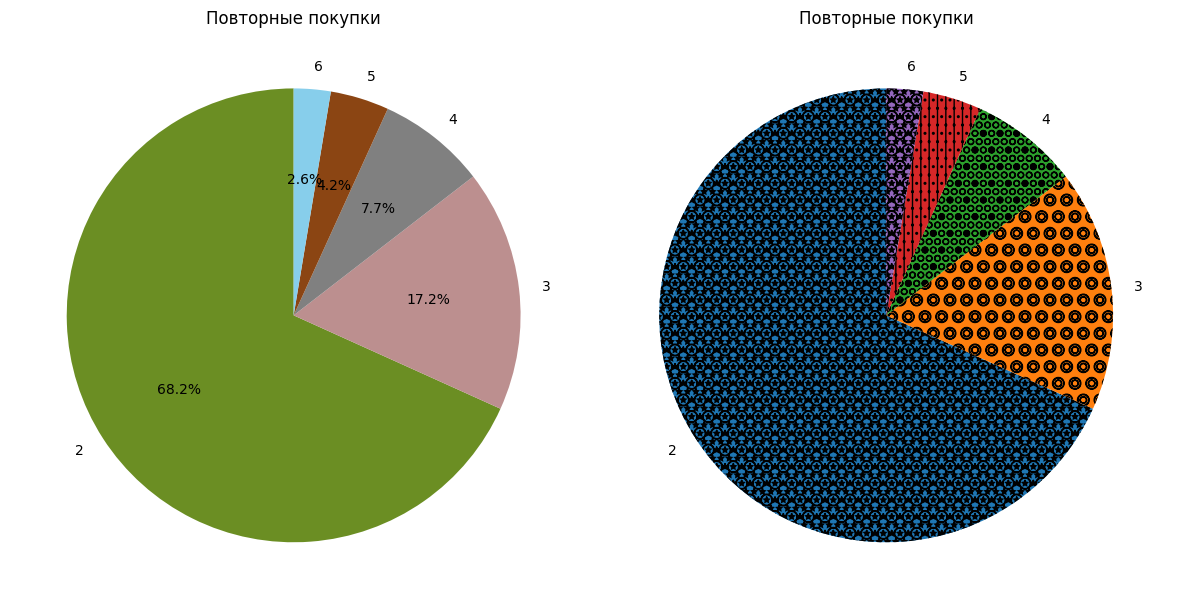

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

item.plot(
    kind='pie',
    ax=axes[0],
    autopct='%1.1f%%',
    startangle=90,
    title='Повторные покупки',
    ylabel='',
    colors=['olivedrab', 'rosybrown', 'gray', 'saddlebrown', 'skyblue']
)

item.plot(
    kind='pie',
    ax=axes[1],
    startangle=90,
    title='Повторные покупки',
    ylabel='',
    hatch=['**O', 'oO', 'O.O', '.||.']
)

plt.tight_layout()
plt.show()

In [31]:
# количество товаров купленных повторно
repest_products = count_user[count_user['product_purch'] > 1] \
    .groupby('survey_responseid') \
    .size() \
    .reset_index(name='repeat_product') \
    .rename(columns={'survey_responseid':'user_id'})
repest_products.sort_values(by='repeat_product', ascending=False)


,user_id,repeat_product
1167,R_24csoaO569P4Yzz,417
3520,R_8CXcySQawXPuJwJ,405
2551,R_3G1gYo1d23Zq8Np,354
1695,R_2VyUSFk11bbTVej,352
4103,R_bJI8lmXMZWL6oql,351
...,...,...
538,R_1Q3YqoPwNpKkGrB,1
537,R_1Q3AyE3HMTBGZ4v,1
1312,R_294j7DOOunkaWAs,1
1304,R_28NaRbv2bvDrApB,1


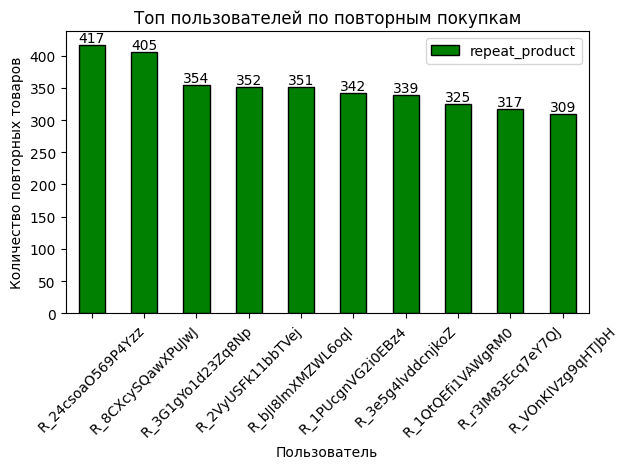

In [32]:
top_users = repest_products.nlargest(10, 'repeat_product')
ax = top_users.plot(
    kind='bar',
    x='user_id',
    y='repeat_product',
    color='green',
    edgecolor='black',
    rot=45
)

ax.bar_label(ax.containers[0])

plt.title('Топ пользователей по повторным покупкам')
plt.xlabel('Пользователь')
plt.ylabel('Количество повторных товаров')

plt.tight_layout()
plt.show()

Удалим 2 столбца, потому что они не несут никакой информативности

In [33]:
data_purchases = data_purchases.drop(['RESULT'], axis=1)

In [34]:
data_purchases

,order_date,purchase_price_per_unit,quantity,shipping_address_state,title,asin_isbn,category,survey_responseid
0,2018-12-04,7.98,1.0,NJ,SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...,B0143RTB1E,FLASH_MEMORY,R_01vNIayewjIIKMF
1,2018-12-22,13.99,1.0,NJ,Betron BS10 Earphones Wired Headphones in Ear ...,B01MA1MJ6H,HEADPHONES,R_01vNIayewjIIKMF
2,2018-12-24,8.99,1.0,NJ,Uknown,B078JZTFN3,Uknown,R_01vNIayewjIIKMF
3,2018-12-25,10.45,1.0,NJ,Perfecto Stainless Steel Shaving Bowl. Durable...,B06XWF9HML,DISHWARE_BOWL,R_01vNIayewjIIKMF
4,2018-12-25,10.00,1.0,NJ,Proraso Shaving Cream for Men,B00837ZOI0,SHAVING_AGENT,R_01vNIayewjIIKMF
...,...,...,...,...,...,...,...,...
1850712,2021-04-01,6.99,1.0,MA,Tanner's Tasty Paste Vanilla Bling - Anticavit...,B015ZRTHVA,TOOTH_CLEANING_AGENT,R_zfqnsBzlOAKibzb
1850713,2021-04-14,15.99,1.0,MA,Sinland Microfiber Cleaning Cloth Dish Cloth K...,B00QGCXPRG,TOWEL,R_zfqnsBzlOAKibzb
1850714,2021-05-22,6.99,4.0,MA,Tanner's Tasty Paste Vanilla Bling - Anticavit...,B015ZRTHVA,TOOTH_CLEANING_AGENT,R_zfqnsBzlOAKibzb
1850715,2021-12-01,6.99,4.0,MA,Tanner's Tasty Paste Vanilla Bling - Anticavit...,B015ZRTHVA,TOOTH_CLEANING_AGENT,R_zfqnsBzlOAKibzb


Работаем с преобразованием

In [35]:
data = data_purchases.copy()

In [36]:
data

,order_date,purchase_price_per_unit,quantity,shipping_address_state,title,asin_isbn,category,survey_responseid
0,2018-12-04,7.98,1.0,NJ,SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...,B0143RTB1E,FLASH_MEMORY,R_01vNIayewjIIKMF
1,2018-12-22,13.99,1.0,NJ,Betron BS10 Earphones Wired Headphones in Ear ...,B01MA1MJ6H,HEADPHONES,R_01vNIayewjIIKMF
2,2018-12-24,8.99,1.0,NJ,Uknown,B078JZTFN3,Uknown,R_01vNIayewjIIKMF
3,2018-12-25,10.45,1.0,NJ,Perfecto Stainless Steel Shaving Bowl. Durable...,B06XWF9HML,DISHWARE_BOWL,R_01vNIayewjIIKMF
4,2018-12-25,10.00,1.0,NJ,Proraso Shaving Cream for Men,B00837ZOI0,SHAVING_AGENT,R_01vNIayewjIIKMF
...,...,...,...,...,...,...,...,...
1850712,2021-04-01,6.99,1.0,MA,Tanner's Tasty Paste Vanilla Bling - Anticavit...,B015ZRTHVA,TOOTH_CLEANING_AGENT,R_zfqnsBzlOAKibzb
1850713,2021-04-14,15.99,1.0,MA,Sinland Microfiber Cleaning Cloth Dish Cloth K...,B00QGCXPRG,TOWEL,R_zfqnsBzlOAKibzb
1850714,2021-05-22,6.99,4.0,MA,Tanner's Tasty Paste Vanilla Bling - Anticavit...,B015ZRTHVA,TOOTH_CLEANING_AGENT,R_zfqnsBzlOAKibzb
1850715,2021-12-01,6.99,4.0,MA,Tanner's Tasty Paste Vanilla Bling - Anticavit...,B015ZRTHVA,TOOTH_CLEANING_AGENT,R_zfqnsBzlOAKibzb


In [37]:
# преобразуем дату в тип переменных дата
data['order_date'] = pd.to_datetime(data['order_date'])

In [38]:
#создадим колонку деньги за заказ
data['total_price'] = data['purchase_price_per_unit'] * data['quantity']

Разделим признаки для предсказания до и после и рассчитывать rfm и другие только для past

In [39]:
cutoff_date = '2021-01-01'
past = data[data['order_date']  < cutoff_date ]
future = data[data['order_date'] >= cutoff_date]

In [40]:
# аггрегируем столбцы, чтобы понимать какие значения могут быть необходимы
df_past = past.groupby('survey_responseid').agg(
    total_revenue=('total_price','sum'),
    num_order = ('order_date','count'),
    total_quantity=('quantity','sum'),
    avg_unit_price = ('purchase_price_per_unit', 'mean'),
    first_order_date=('order_date', 'min'),
    last_order_date=('order_date', 'max')
).reset_index().rename(columns={'survey_responseid': 'user_id'})

In [41]:
#посчитаем колво дней от интервала до последней покупки
df_past['recency'] = (pd.to_datetime(cutoff_date) - df_past['last_order_date']).dt.days
#срок службы клиента
df_past['customer_age'] = (pd.to_datetime(cutoff_date) - df_past['first_order_date']).dt.days
#срок владения
df_past['tenure'] = (df_past['last_order_date'] - df_past['first_order_date']).dt.days
#среднее количество заказов??
df_past['avg_order_value'] = round((df_past['total_revenue']/df_past['num_order']), 2)

сколько заказов в день жизни клиента

In [42]:
df_past['purchase_frequency_rate'] = round(df_past['num_order']/df_past['customer_age'], 2)

Средний интервал между покупками

In [43]:
df_past['avg_days_between_orders'] = round((df_past['tenure']/df_past['num_order']), 2)

Насколько давно он пропал относительно своей жизни

In [44]:
df_past['recency_normalized'] = round((df_past['recency']/df_past['customer_age']), 5)

Выручка на единицу времени - ценность клиента во времени

In [45]:
df_past['revenue_per_day'] = round((df_past['total_revenue']/ df_past['customer_age']), 2)

Средний размер заказа (товары) - сколько товаров в зз

In [46]:
df_past['average_order_size'] = round((df_past['total_quantity']/df_past['num_order']))

Количество категорий для чего надо

→ насколько разнообразно ведёт себя пользователь

покупает в одной категории → узкий профиль

покупает в разных → широкий профиль

Часто:
→ чем больше категорий → тем выше LTV

In [47]:
category_features = past.groupby('survey_responseid').agg(
    category_count=('category', 'nunique')
).reset_index().rename(columns={'survey_responseid': 'user_id'})

In [48]:
df = df_past.merge(category_features, on='user_id', how='left')
df

,user_id,total_revenue,num_order,total_quantity,avg_unit_price,first_order_date,last_order_date,recency,customer_age,tenure,avg_order_value,purchase_frequency_rate,avg_days_between_orders,recency_normalized,revenue_per_day,average_order_size,category_count
0,R_01vNIayewjIIKMF,1933.84,89,93.0,20.328652,2018-12-04,2020-08-28,126,759,633,21.73,0.12,7.11,0.16601,2.55,1.0,40
1,R_037XK72IZBJyF69,7097.24,457,493.0,14.902757,2018-01-18,2020-12-31,1,1079,1078,15.53,0.42,2.36,0.00093,6.58,1.0,212
2,R_038ZU6kfQ5f89fH,1632.83,30,33.0,47.103333,2018-12-18,2020-12-18,14,745,731,54.43,0.04,24.37,0.01879,2.19,1.0,18
3,R_03aEbghUILs9NxD,1028.37,55,55.0,18.697636,2018-01-13,2020-02-27,309,1084,775,18.70,0.05,14.09,0.28506,0.95,1.0,39
4,R_06RZP9pS7kONINr,4819.42,197,213.0,23.428477,2018-01-23,2020-12-29,3,1074,1071,24.46,0.18,5.44,0.00279,4.49,1.0,101
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4877,R_zd4E1BgAdaM2761,5755.80,242,259.0,22.903719,2018-01-14,2020-12-22,10,1083,1073,23.78,0.22,4.43,0.00923,5.31,1.0,127
4878,R_zdLOP8JD2pe1brj,2689.68,116,126.0,22.423276,2018-02-20,2020-12-20,12,1046,1034,23.19,0.11,8.91,0.01147,2.57,1.0,67
4879,R_zdQYFhfeqyBd2dH,1151.71,50,50.0,23.034200,2019-12-19,2020-12-04,28,379,351,23.03,0.13,7.02,0.07388,3.04,1.0,39
4880,R_zfnsck2ZatnGtY5,4954.94,289,308.0,16.577301,2018-01-11,2020-12-20,12,1086,1074,17.15,0.27,3.72,0.01105,4.56,1.0,146


Предскажем целевую переменную

In [49]:
df_future = future.groupby('survey_responseid').agg(
    ltv=('total_price', 'sum')
).reset_index().rename(columns={'survey_responseid':'user_id'})
df_future['ltv'] = df_future['ltv'].fillna(0)

In [50]:
df = df_past.merge(df_future,on='user_id', how='left')

# EDA analysis


In [51]:
df['ltv'] = df['ltv'].fillna(0)

In [52]:
df['ltv_log'] = np.log1p(df['ltv'])

In [53]:
df.isna().sum()

,0
user_id,0
total_revenue,0
num_order,0
total_quantity,0
avg_unit_price,0
first_order_date,0
last_order_date,0
recency,0
customer_age,0
tenure,0


In [54]:
num_cols = [
    'ltv','ltv_log', 'total_revenue', 'num_order', 'total_quantity',
    'purchase_frequency_rate', 'avg_days_between_orders',
    'recency', 'recency_normalized', 'revenue_per_day',
    'avg_unit_price', 'avg_order_value', 'average_order_size',
    'customer_age', 'tenure'
]

df[num_cols].describe(percentiles=[0.01, 0.05, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,50%,95%,99%,max
ltv,4882.0,4621.467016,5347.970056,0.00000,3.587200,187.523500,2966.435000,14508.781000,24581.636100,75077.590000
ltv_log,4882.0,7.750710,1.490468,0.00000,1.502342,5.239222,7.995453,9.582578,10.109794,11.226291
total_revenue,4882.0,4358.614244,5179.882037,3.93000,29.919700,130.491000,2638.260000,14535.997000,24537.337500,60848.980000
num_order,4882.0,184.492626,224.618126,1.00000,1.000000,7.000000,110.000000,619.950000,1080.570000,2298.000000
total_quantity,4882.0,200.776116,250.811446,1.00000,1.810000,7.000000,117.000000,683.000000,1212.570000,2606.000000
purchase_frequency_rate,4882.0,0.183773,0.215923,0.00000,0.000000,0.010000,0.120000,0.590000,1.021900,3.000000
avg_days_between_orders,4882.0,16.895948,26.744607,0.00000,0.000000,1.400000,8.020000,62.616500,133.595000,360.500000
recency,4882.0,47.788202,124.016301,1.00000,1.000000,1.000000,10.000000,239.000000,722.950000,1096.000000
recency_normalized,4882.0,0.068062,0.179825,0.00091,0.000910,0.000920,0.010160,0.421064,1.000000,1.000000
revenue_per_day,4882.0,4.330795,4.922016,0.01000,0.060000,0.210000,2.720000,13.690000,23.444600,55.570000


In [55]:
df.duplicated().sum()

np.int64(0)

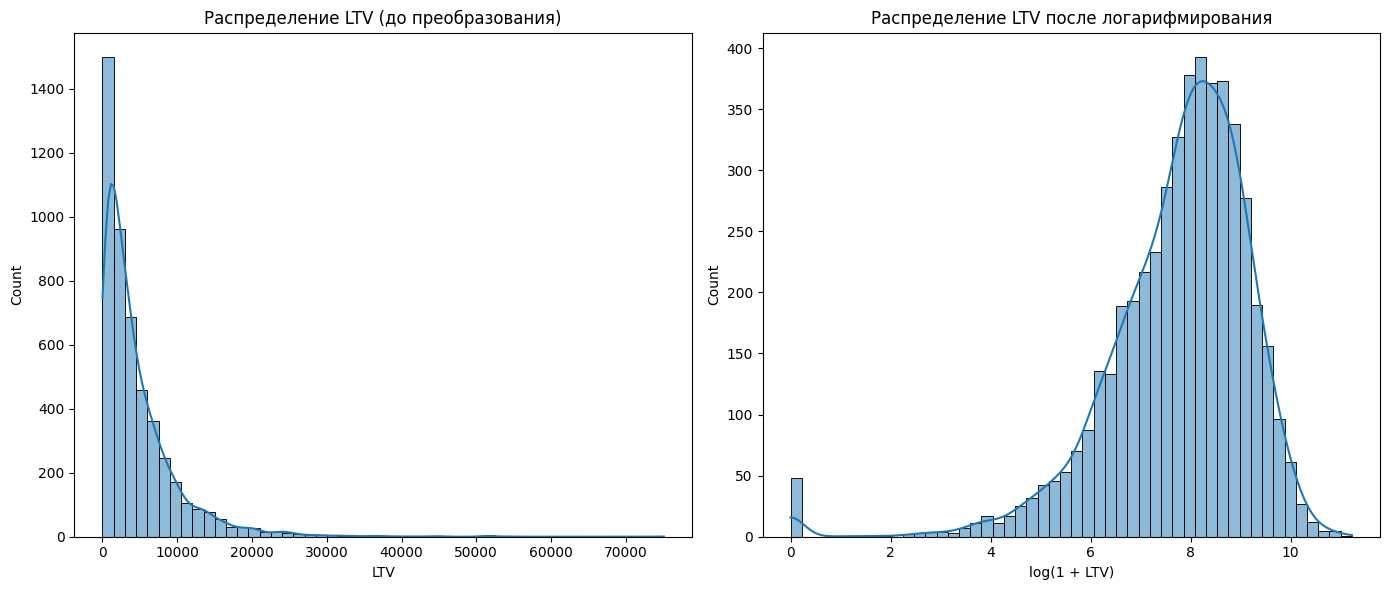

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(df['ltv'], kde=True, bins=50, ax=axes[0])
axes[0].set_title('Распределение LTV (до преобразования)')
axes[0].set_xlabel('LTV')

sns.histplot(df['ltv_log'], kde=True, bins=50, ax=axes[1])
axes[1].set_title('Распределение LTV после логарифмирования')
axes[1].set_xlabel('log(1 + LTV)')

plt.tight_layout()
plt.show()

In [57]:
df.isna().sum()

,0
user_id,0
total_revenue,0
num_order,0
total_quantity,0
avg_unit_price,0
first_order_date,0
last_order_date,0
recency,0
customer_age,0
tenure,0


Посмотрим повторяющиеся покупки

In [58]:
df.corr(numeric_only=True)['ltv_log'].sort_values()

,ltv_log
recency,-0.459697
recency_normalized,-0.454797
avg_days_between_orders,-0.435212
avg_unit_price,-0.039283
average_order_size,-0.026499
avg_order_value,-0.026356
customer_age,0.262316
tenure,0.427174
purchase_frequency_rate,0.527929
total_quantity,0.528596


In [59]:
df['total_revenue_log'] = np.log1p(df['total_revenue'])
df['recency_log'] = np.log1p(df['recency'])
df['tenure_log'] = np.log1p(df['tenure'])
df['customer_age_log'] = np.log1p(df['customer_age'])
df['avg_days_between_orders_log'] = np.log1p(df['avg_days_between_orders'])
df['revenue_per_day_log'] = np.log1p(df['revenue_per_day'])
df['purchase_frequency_rate_sqrt'] = np.sqrt(df['purchase_frequency_rate'])

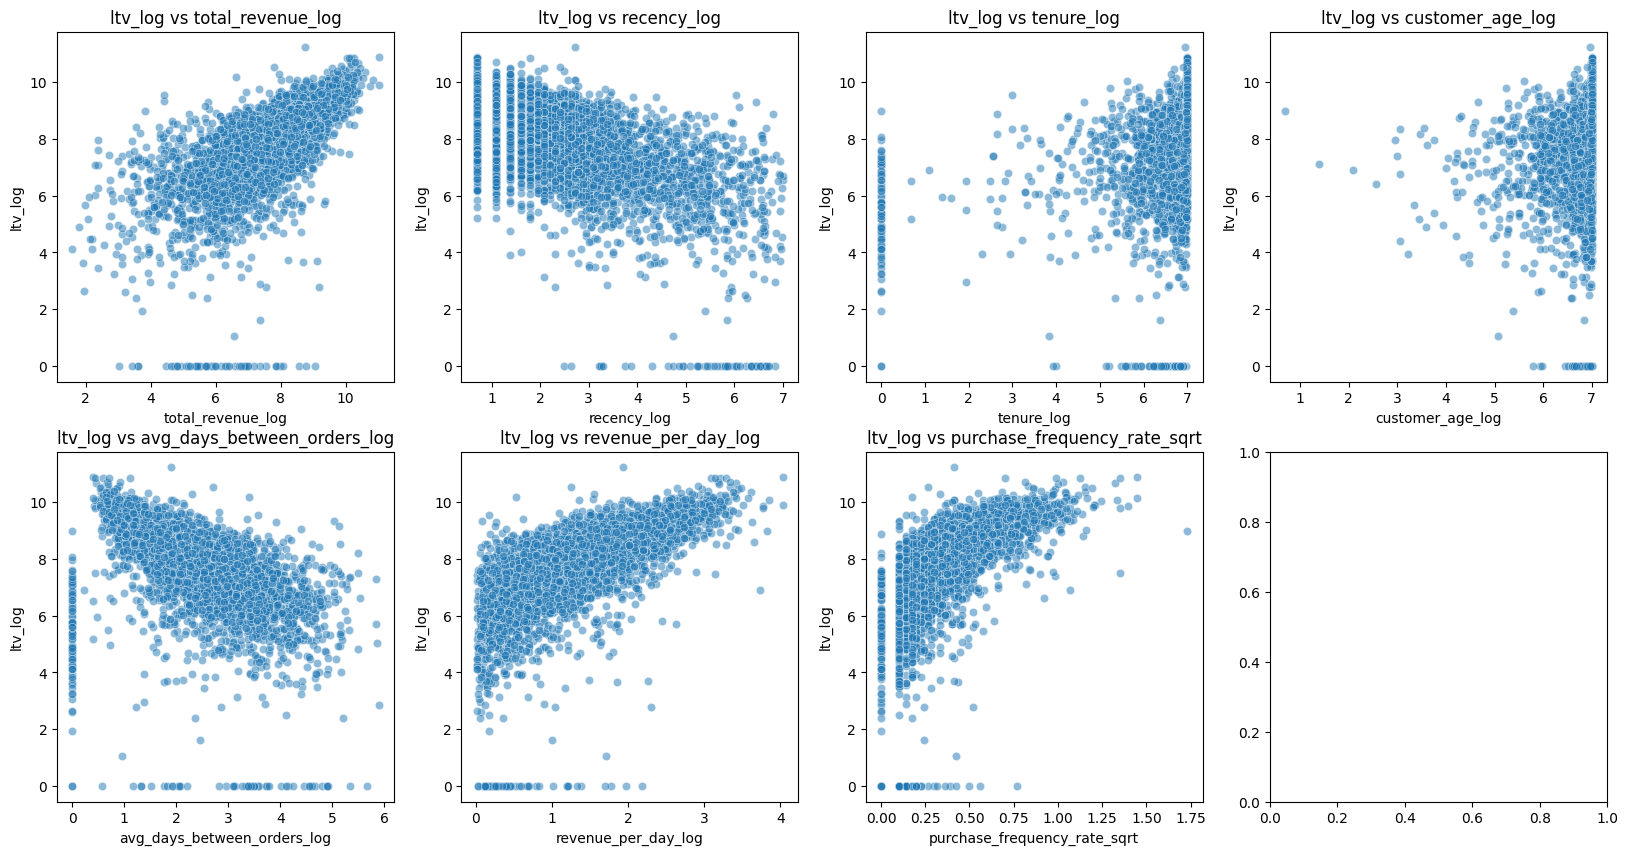

In [60]:
selected_features = ['total_revenue_log', 'recency_log', 'tenure_log',
                     'customer_age_log', 'avg_days_between_orders_log',
                     'revenue_per_day_log', 'purchase_frequency_rate_sqrt']

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()

for idx, feature in enumerate(selected_features):  # ← по вашему списку
    sns.scatterplot(data=df, x=feature, y='ltv_log', ax=axes[idx], alpha=0.5)
    axes[idx].set_title(f'ltv_log vs {feature}')

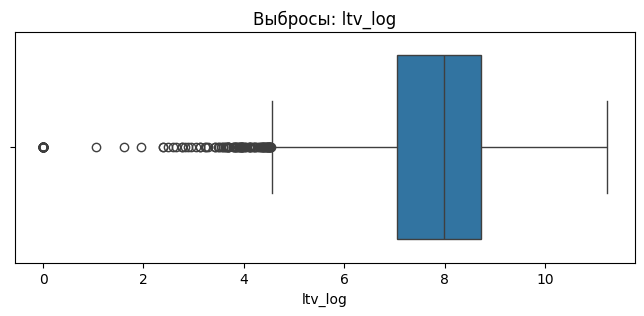

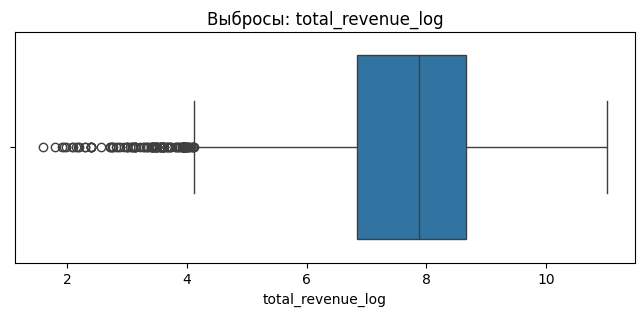

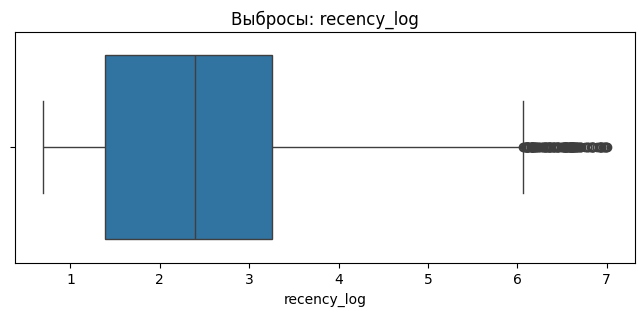

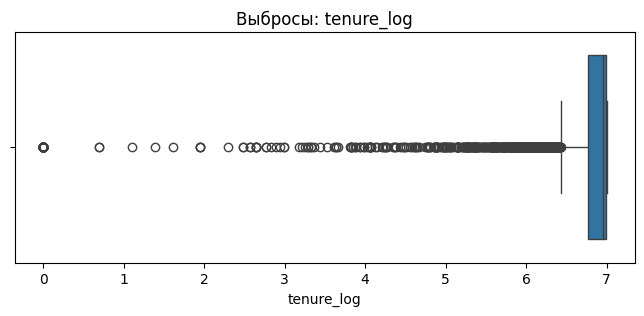

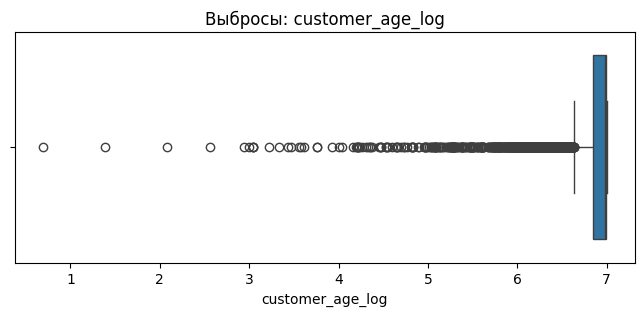

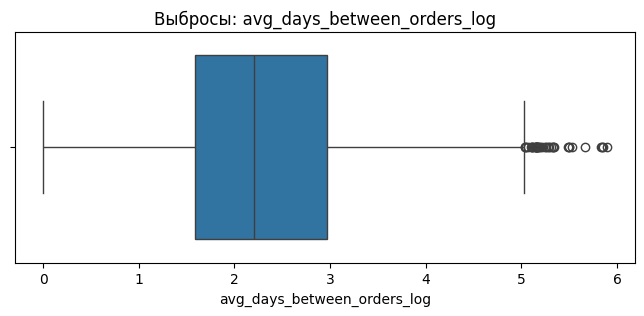

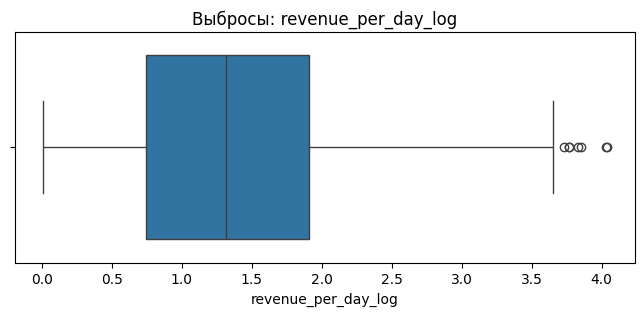

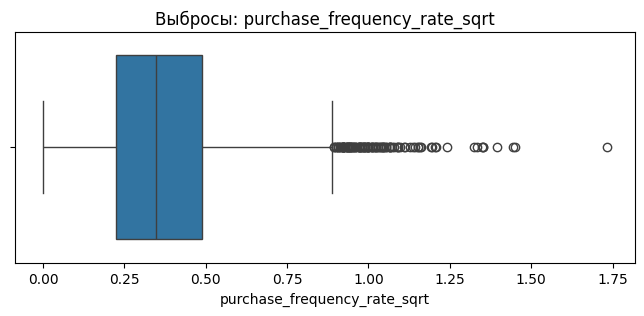

In [61]:
num_cols = ['ltv_log',
'total_revenue_log',
'recency_log',
'tenure_log',
'customer_age_log',
'avg_days_between_orders_log',
'revenue_per_day_log',
'purchase_frequency_rate_sqrt']
for col in num_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Выбросы: {col}')
    plt.show()

# Machine learning

In [62]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score

In [63]:
X = df[['num_order',
        'total_quantity',
        'avg_unit_price',
        'avg_order_value',
        'purchase_frequency_rate_sqrt',
        'avg_days_between_orders_log',
        'recency_log',
        'customer_age_log',
        'tenure_log',
        'revenue_per_day_log',
        'average_order_size']]
y = df['ltv_log']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state= 2023)

In [64]:
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (3661, 11), y_train: (3661,)
X_test: (1221, 11), y_test: (1221,)


Рассмотрим целевую переменную

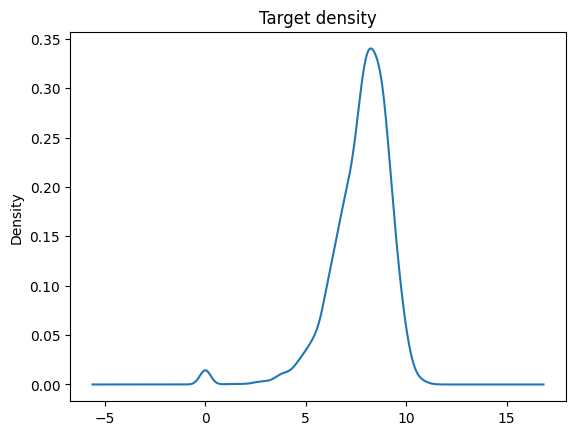

In [65]:
y.plot(kind='kde', title='Target density');

Dummy Regressor — базовая модель, которая предсказывает медиану


In [66]:
dummy_clf = DummyRegressor(strategy="median")
dummy_clf.fit(X_train, y_train)
y_pred_dummy = dummy_clf.predict(X_test)

In [67]:
# используются только для задач классификации, а у меня регрессия
# confusion_matrix(y_test, y_pred_dummy)

Используем StandartScaler для линейной модели. Используется для изменения размера распределения значений так, чтобы среднее значение наблюдаемых значений было равно 0, а стандартное отклонение – 1

In [68]:
lr = LinearRegression()


good_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", lr)
])

good_pipe.fit(X_train, y_train)
y_preds_lr = good_pipe.predict(X_test)


In [69]:
print(f'MSE for Dummy Regressor: {mean_squared_error(y_test, y_pred_dummy)}')
print(f'MSE for Linear regression: {mean_squared_error(y_test, y_preds_lr)}')

print(f'RMSE for Dummy Regressor: {root_mean_squared_error(y_test, y_pred_dummy)}')
print(f'RMSE for Linear regression: {root_mean_squared_error(y_test, y_preds_lr)}')

MSE for Dummy Regressor: 2.35907644487751
MSE for Linear regression: 1.0679300848938813
RMSE for Dummy Regressor: 1.5359285285707502
RMSE for Linear regression: 1.0334070276971612


In [70]:
def make_graph(actual, prediction, name):
  plt.figure(figsize=(12,8))
  results = pd.DataFrame({'True': actual, 'Prediction': prediction})
  sns.lmplot(x='True', y='Prediction', data=results, fit_reg=False)
  d_line = np.arange(results.min().min(), results.max().max())
  plt.plot(d_line, d_line, color='red', linestyle='--')
  plt.title = name
  plt.grid()
  plt.show()

<Figure size 1200x800 with 0 Axes>

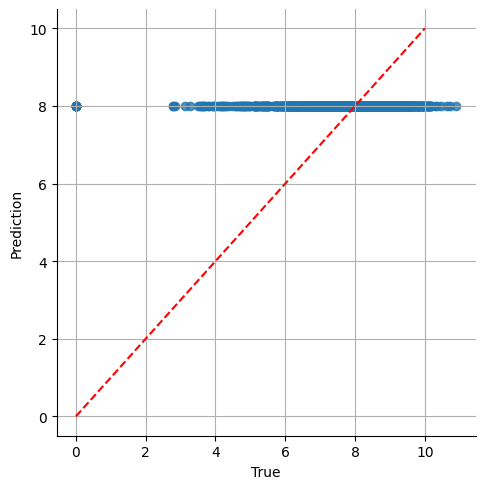

In [71]:
make_graph(y_test, y_pred_dummy, name='dummy')

<Figure size 1200x800 with 0 Axes>

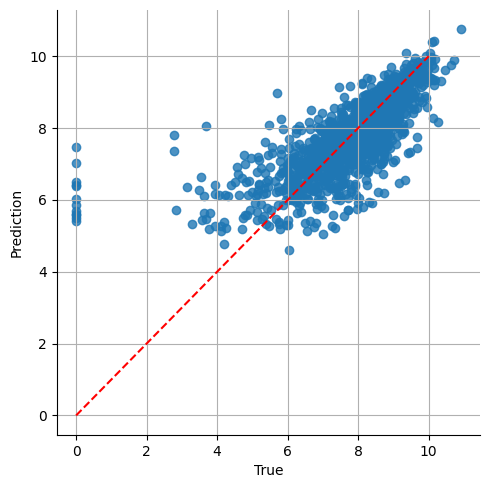

In [72]:
make_graph(y_test, y_preds_lr, name='Linear Regression')

In [73]:
print(f'MAE for Dummy Regressor: {mean_absolute_error(y_test, y_pred_dummy)}')
print(f'MAE for Linear regression: {mean_absolute_error(y_test, y_preds_lr)}')

print(f'R2 for Dummy Regressor: {r2_score(y_test, y_pred_dummy)}')
print(f'R2 for Linear regression: {r2_score(y_test, y_preds_lr)}')

MAE for Dummy Regressor: 1.0762011472340491
MAE for Linear regression: 0.6600735873519635
R2 for Dummy Regressor: -0.02596708111100643
R2 for Linear regression: 0.5355550624871359


Используем модель ridge(почитать про модель) ❗

In [74]:
rdg_pipeline = Pipeline([
    ('scales', StandardScaler()),
    ('ridge', Ridge())
])

params = {
    'ridge__alpha': [0.01, 0.1, 1, 10, 100]
}

ridge_search = GridSearchCV(
    rdg_pipeline,
    params,
    cv=5)

ridge_search.fit(X_train, y_train)
y_preds_rdg = ridge_search.predict(X_test)

In [75]:
print(f'Best Ridge parameters: {ridge_search.best_params_}')

print(f'MSE Ridge: {mean_squared_error(y_test, y_preds_rdg)}')
print(f'RMSE Ridge: {root_mean_squared_error(y_test, y_preds_rdg)}')
print(f'MAE Ridge: {mean_absolute_error(y_test, y_preds_rdg)}')
print(f'R2 Ridge: {r2_score(y_test, y_preds_rdg)}')

Best Ridge parameters: {'ridge__alpha': 10}
MSE Ridge: 1.0683304774583453
RMSE Ridge: 1.0336007340643414
MAE Ridge: 0.6599160778592372
R2 Ridge: 0.5353809309571663


In [76]:
lasso_pipeline = Pipeline([
    ('scales', StandardScaler()),
    ('lasso', Lasso())
])

params = {
    'lasso__alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

lasso_search = GridSearchCV(
    lasso_pipeline,
    params,
    cv=5)

lasso_search.fit(X_train, y_train)
y_preds_lasso = lasso_search.predict(X_test)

In [77]:
print(f'Best Lasso parameters: {lasso_search.best_params_}')

print(f'MSE Lasso: {mean_squared_error(y_test, y_preds_lasso)}')
print(f'RMSE Lasso: {root_mean_squared_error(y_test, y_preds_lasso)}')
print(f'MAE Lasso: {mean_absolute_error(y_test, y_preds_lasso)}')
print(f'R2 Lasso: {r2_score(y_test, y_preds_lasso)}')

Best Lasso parameters: {'lasso__alpha': 0.001}
MSE Lasso: 1.0684556944894414
RMSE Lasso: 1.0336613055007144
MAE Lasso: 0.6596360429865028
R2 Lasso: 0.535326473819002


Теперь проверим **Random Forest** и **XGBoost** (Extreme Gradient Boosting)

In [78]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

RandomForest

In [79]:
# функция для оценки моделей

def evaluate_model(name, y_true, y_pred):
    return {
        'model': name,
        'MSE': mean_squared_error(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }

In [80]:
results = []

<Figure size 1200x800 with 0 Axes>

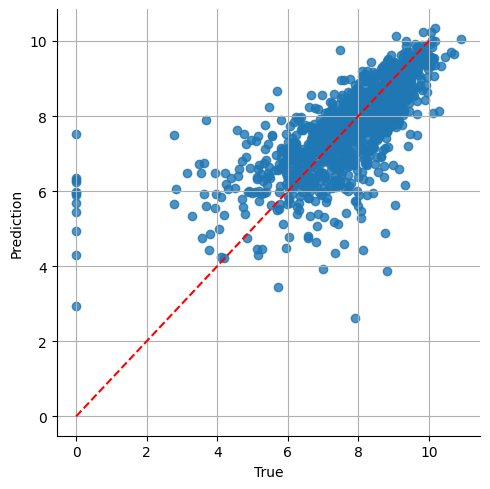

In [81]:
# Random Forest без подбора параметров

rf = RandomForestRegressor(random_state=2023)
rf.fit(X_train, y_train)

y_preds_rf = rf.predict(X_test)

results.append(evaluate_model('Random Forest', y_test, y_preds_rf))

make_graph(y_test, y_preds_rf, name='Random Forest')

In [90]:
rf = RandomForestRegressor(random_state=2023)
parameters = {
    'n_estimators': [100],
    'max_depth': [10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True]

}

rf_classifier = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=2023, n_jobs=-1),
    param_distributions=parameters,
    # n_iter=30,          # вместо всех 216 комбинаций
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=2,
    random_state=2023
)

rf_classifier.fit(X_train, y_train)


Fitting 3 folds for each of 8 candidates, totalling 24 fits


RandomizedSearchCV(cv=3,
                   estimator=RandomForestRegressor(n_jobs=-1,
                                                   random_state=2023),
                   n_jobs=-1,
                   param_distributions={'bootstrap': [True],
                                        'max_depth': [10, None],
                                        'min_samples_leaf': [1, 2],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [100]},
                   random_state=2023, scoring='neg_root_mean_squared_error',
                   verbose=2)

In [91]:
y_preds_param_rf = rf_classifier.best_estimator_.predict(X_test)

print('Best Random Forest parameters:', rf_classifier.best_params_)

Best Random Forest parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10, 'bootstrap': True}


In [92]:
print('R2:', r2_score(y_test, y_preds_param_rf))
print('RMSE:', root_mean_squared_error(y_test, y_preds_param_rf))
print('MSE:', mean_squared_error(y_test, y_preds_param_rf))


R2: 0.5151088254728763
RMSE: 1.0559088593977484
MSE: 1.114943519354654


XGB Regressor

In [93]:
xgb = XGBRegressor(objective='reg:squarederror')
xgb.fit(X_train, y_train)
y_preds_xgd = xgb.predict(X_test)

In [94]:
print('RMSE:', root_mean_squared_error(y_test, y_preds_xgd))
print('MSE:', mean_squared_error(y_test, y_preds_xgd))
print('MAE:', mean_absolute_error(y_test, y_preds_xgd))
print('R2:', r2_score(y_test, y_preds_xgd))

RMSE: 1.1557486658078557
MSE: 1.3357549785166387
MAE: 0.7430332372067773
R2: 0.4190774786616259


In [109]:
model = XGBRegressor()
parameters = {
    'learning_rate': [0.02, 0.03, 0.05],
    'max_depth': [3, 4, 5],
    'n_estimators': [200, 300, 400],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.05, 0.1],
    'reg_lambda': [1, 3, 5]
}

xgb_random_search = RandomizedSearchCV(
    model,
    parameters,
    n_iter=30,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=2023,
    verbose=2
)

xgb_random_search.fit(X_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 0.9, 1.0],
                                        'gamma': [0, 0.05, 0.1],
                                        'learning_rate': [0.02, 0.03, 0.05],
                                        'max_depth': [3, 4, 5],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [200, 300, 400],
                                        'reg_lambda': [1, 3, 5],
                                        'subsample': [0.8, 0.9]},
                   random_state=2023, scoring='r2', verbose=2)

In [107]:
y_preds_xgdr = xgb_random_search.best_estimator_.predict(X_test)

In [108]:
print('RMSE:', root_mean_squared_error(y_test, y_preds_xgdr))
print('MSE:', mean_squared_error(y_test, y_preds_xgdr))
print('MAE:', mean_absolute_error(y_test, y_preds_xgdr))
print('R2:', r2_score(y_test, y_preds_xgdr))

RMSE: 1.035953695910651
MSE: 1.0732000600709375
MAE: 0.6609796103959842
R2: 0.5332631397045265


# Assesment of features

In [ ]:
%%capture
# !pip install lime
import lime
import lime.lime_tabular

In [ ]:
explainer = lime.lime_tabular.LimeTabularExplainer(X_train.values, feature_names=X_train.columns.values.tolist(),
                                                   class_names=['MEDV'], verbose=True, mode='regression')

In [ ]:
j = 5
exp = explainer.explain_instance(X_test.values[j], rf.predict, num_features=6)